In [133]:
!pip install --upgrade meteostat

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv('/content/Master data aqi.csv', parse_dates=['Date'], index_col=['Date'])

In [135]:
df1.head()

,Year,Month,Day of Year,AQI (Raw)
Date,,,,
2017-11-01,2017,November,305,64.0
2017-11-02,2017,November,306,47.0
2017-11-03,2017,November,307,52.0
2017-11-04,2017,November,308,49.0
2017-11-05,2017,November,309,56.0


In [136]:
df1.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2708 entries, 2017-11-01 to 2025-03-31
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         2708 non-null   int64  
 1   Month        2708 non-null   str    
 2   Day of Year  2708 non-null   int64  
 3   AQI (Raw)    2700 non-null   float64
dtypes: float64(1), int64(2), str(1)
memory usage: 122.2 KB


In [137]:
df1 = df1.drop(columns=['Month', 'Year', 'Day of Year'])

In [138]:
df1.head()

,AQI (Raw)
Date,
2017-11-01,64.0
2017-11-02,47.0
2017-11-03,52.0
2017-11-04,49.0
2017-11-05,56.0


Let us introdice the weather data of Chennai from the desired years using meteostat library of python.

This is very crucial because weather is the most important exogenous variable for aqi.

This will require *latitude and longitude* of Chennai. You will also pass the range of the date.

In [139]:
# !pip install meteostat

In [140]:
print(df1.index.min())
print(df1.index.max())

2017-11-01 00:00:00
2025-03-31 00:00:00


In [141]:
from meteostat import daily, stations
from datetime import datetime

#Chennai Airport
station_id = '43279'
start = datetime(2017, 11, 1)
end = datetime(2025, 3, 31)

data = daily(station_id, start, end)
weather_df = data.fetch()

if weather_df is None or weather_df.empty:
    print("Warning: No data found! Try checking your internet or station ID.")
else:
    weather_df = weather_df.reset_index()
    weather_df.rename(columns={'time': 'Date'}, inplace=True)

    weather_df['prcp'] = weather_df['prcp'].fillna(0)
    print("Weather data fetched successfully!")

Weather data fetched successfully!


In [142]:
weather_df.head()

,Date,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
0,2017-11-01,24.9,21.6,28.5,95,7.9,<NA>,8.2,<NA>,1011.4,<NA>,<NA>
1,2017-11-02,25.8,22.2,30.0,91,23.9,<NA>,8.9,<NA>,1010.3,<NA>,<NA>
2,2017-11-03,25.5,22.2,30.4,90,141.0,<NA>,10.4,<NA>,1009.6,<NA>,<NA>
3,2017-11-04,25.2,21.5,28.9,96,62.0,<NA>,5.4,<NA>,1009.7,<NA>,<NA>
4,2017-11-05,26.8,23.2,30.0,90,20.1,<NA>,8.4,<NA>,1010.2,<NA>,<NA>


In [143]:
weather_df.tail(10)

,Date,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
2698,2025-03-22,30.3,26.8,34.6,76,3.3,<NA>,12.1,<NA>,1012.8,<NA>,5
2699,2025-03-23,30.4,27.4,34.6,74,0.0,<NA>,11.1,<NA>,1012.6,<NA>,5
2700,2025-03-24,30.0,27.0,34.0,74,0.0,<NA>,10.9,<NA>,1012.0,<NA>,4
2701,2025-03-25,29.4,26.0,34.0,72,0.0,<NA>,9.7,<NA>,1009.6,<NA>,3
2702,2025-03-26,29.5,25.0,33.4,74,0.0,<NA>,10.7,<NA>,1008.1,<NA>,2
2703,2025-03-27,31.0,26.0,38.0,69,0.0,<NA>,8.4,<NA>,1007.4,<NA>,3
2704,2025-03-28,30.9,26.6,36.0,73,0.0,<NA>,11.5,<NA>,1006.7,<NA>,4
2705,2025-03-29,31.5,25.8,38.4,64,0.0,<NA>,11.2,<NA>,1006.9,<NA>,2
2706,2025-03-30,29.9,26.0,34.8,72,0.0,<NA>,12.6,<NA>,1008.3,<NA>,3
2707,2025-03-31,29.2,25.6,33.6,72,0.0,<NA>,9.7,<NA>,1008.8,<NA>,3


In [144]:
weather_df['Date'] = pd.to_datetime(weather_df['Date'])

In [145]:
df = df1.merge(weather_df, on='Date', how='left')

print(len(df1))
print(len(df))


2708
2708


In [146]:
df.head()

,Date,AQI (Raw),temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
0,2017-11-01,64.0,24.9,21.6,28.5,95,7.9,<NA>,8.2,<NA>,1011.4,<NA>,<NA>
1,2017-11-02,47.0,25.8,22.2,30.0,91,23.9,<NA>,8.9,<NA>,1010.3,<NA>,<NA>
2,2017-11-03,52.0,25.5,22.2,30.4,90,141.0,<NA>,10.4,<NA>,1009.6,<NA>,<NA>
3,2017-11-04,49.0,25.2,21.5,28.9,96,62.0,<NA>,5.4,<NA>,1009.7,<NA>,<NA>
4,2017-11-05,56.0,26.8,23.2,30.0,90,20.1,<NA>,8.4,<NA>,1010.2,<NA>,<NA>


In [147]:
df['Date'] = pd.to_datetime(df['Date'])

In [148]:
df.head()

,Date,AQI (Raw),temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
0,2017-11-01,64.0,24.9,21.6,28.5,95,7.9,<NA>,8.2,<NA>,1011.4,<NA>,<NA>
1,2017-11-02,47.0,25.8,22.2,30.0,91,23.9,<NA>,8.9,<NA>,1010.3,<NA>,<NA>
2,2017-11-03,52.0,25.5,22.2,30.4,90,141.0,<NA>,10.4,<NA>,1009.6,<NA>,<NA>
3,2017-11-04,49.0,25.2,21.5,28.9,96,62.0,<NA>,5.4,<NA>,1009.7,<NA>,<NA>
4,2017-11-05,56.0,26.8,23.2,30.0,90,20.1,<NA>,8.4,<NA>,1010.2,<NA>,<NA>


## Core Weather Variables

- **temp**: Mean daily air temperature in Celsius ($^\circ$C). This is a key baseline for chemical reaction speeds in the atmosphere.

- **tmin / tmax**: Minimum and maximum air temperature in Celsius ($^\circ$C). Useful for identifying temperature inversions.

- **rhum**: Relative humidity as a percentage (%). High humidity can lead to the formation of secondary particulate matter.

- **prcp**: Precipitation (rainfall) in millimeters (mm). This is often the most important variable for AQI as rain "washes" pollutants out of the air.

---

## Wind and Pressure

- **wspd**: Mean wind speed in kilometers per hour (km/h). Higher speeds generally disperse pollutants, leading to lower AQI.

- **wpgt**: Peak wind gust in kilometers per hour (km/h). In your data, this appears as `<NA>` because it is rarely recorded at the Chennai station daily.

- **pres**: Sea-level air pressure in hectopascals (hPa). High pressure often indicates stagnant air, which can trap pollution.

---

## Clouds and Solar

- **cldc**: Cloud cover in eighths (oktas). Values like 3 or 5 represent how much of the sky is covered.

- **tsun**: Sunshine duration in minutes. Like wpgt, this is often missing (`<NA>`) in standard Indian station reports.

- **snwd**: Snow depth in millimeters (mm). This is irrelevant for Chennai and will remain `<NA>`.

In [149]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2708 entries, 0 to 2707
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2708 non-null   datetime64[us]
 1   AQI (Raw)  2700 non-null   float64       
 2   temp       2708 non-null   Float64       
 3   tmin       2701 non-null   Float64       
 4   tmax       2699 non-null   Float64       
 5   rhum       2708 non-null   UInt8         
 6   prcp       2708 non-null   Float64       
 7   snwd       0 non-null      UInt16        
 8   wspd       2708 non-null   Float64       
 9   wpgt       0 non-null      Float64       
 10  pres       2703 non-null   Float64       
 11  tsun       0 non-null      UInt16        
 12  cldc       975 non-null    UInt8         
dtypes: Float64(7), UInt16(2), UInt8(2), datetime64[us](1), float64(1)
memory usage: 235.5 KB


cldc (cloud cover) is also missing ~64% of its data; as a statistician, you know that imputing that much data can introduce significant imputation bias.

In [150]:
df = df.drop(columns=['snwd', 'wpgt', 'tsun', 'cldc'])

In [151]:
#As we discussed down there below that we will drop temp and tmax so we are dropping them here
df = df.drop(columns=['temp', 'tmax'])

In [152]:
df.rename(columns={'AQI (Raw)': 'AQI'}, inplace=True)

We missed to add lag features earlier and that is the sole reason why our naive1 model was outperforming sarimax by 38%. The reason was that the aqi data has high correlation with aqi_lag_1 as we saw in the heatmap down there (0.75) so we cant let it pass through our sarimax model. Also its very intuitive to think that aqi today is aqi yesterday + some error + some seasonal spike.

That is why lag features are super important.

In [153]:
df['lag1'] = df['AQI'].shift(1)
df['lag7'] = df['AQI'].shift(7)
df['lag14'] = df['AQI'].shift(14)
df = df.dropna(subset=['lag1', 'lag7', 'lag14'])

In [154]:
df.info()

<class 'pandas.DataFrame'>
Index: 2670 entries, 14 to 2707
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2670 non-null   datetime64[us]
 1   AQI     2665 non-null   float64       
 2   tmin    2663 non-null   Float64       
 3   rhum    2670 non-null   UInt8         
 4   prcp    2670 non-null   Float64       
 5   wspd    2670 non-null   Float64       
 6   pres    2665 non-null   Float64       
 7   lag1    2670 non-null   float64       
 8   lag7    2670 non-null   float64       
 9   lag14   2670 non-null   float64       
dtypes: Float64(4), UInt8(1), datetime64[us](1), float64(4)
memory usage: 224.2 KB




---
AQI in India is heavily driven by episodic events and seasonal shifts thus we will try to add seasonal and festive indicator variables.



In [155]:
diwali_dates = ['2017-10-19', '2018-11-07', '2019-10-27', '2020-11-14','2021-11-04', '2022-10-24', '2023-11-12', '2024-10-31', '2025-10-20']
diwali_dates = pd.to_datetime(diwali_dates)

#Diwali_Effect
df['Is_Diwali'] = 0
for d in diwali_dates:
    window = pd.date_range(start=d - pd.Timedelta(days=2), end=d + pd.Timedelta(days=4))
    df.loc[df['Date'].isin(window), 'Is_Diwali'] = 1

In [156]:
def get_monsoon_phase(date):
    month = date.month
    if 1 <= month <= 2:
        return 'Winter_PostMonsoon'
    elif 3 <= month <= 5:
        return 'Summer_PreMonsoon'
    elif 6 <= month <= 9:
        return 'Southwest_Monsoon'
    else: # October to December
        return 'Northeast_Monsoon'

df['Season'] = df['Date'].apply(get_monsoon_phase)



In [157]:
df.head()

,Date,AQI,tmin,rhum,prcp,wspd,pres,lag1,lag7,lag14,Is_Diwali,Season
14,2017-11-15,71.0,23.0,80,2.0,6.6,1006.5,67.0,70.0,64.0,0,Northeast_Monsoon
15,2017-11-16,101.0,24.9,79,0.0,7.9,1007.4,71.0,68.0,47.0,0,Northeast_Monsoon
16,2017-11-17,117.0,26.0,84,0.0,5.3,1008.8,101.0,112.0,52.0,0,Northeast_Monsoon
17,2017-11-18,58.0,25.4,85,0.0,6.5,1009.8,117.0,133.0,49.0,0,Northeast_Monsoon
18,2017-11-19,57.0,25.8,82,0.0,6.4,1011.1,58.0,168.0,56.0,0,Northeast_Monsoon


The COVID-19 lockdown periods (primarily in 2020 and 2021) are what statisticians call an "Exogenous Shock" to our data. In Chennai, AQI improved by approximately 25% to 70% during these phases because vehicular and industrial emissions nearly vanished.

We cannot treat these days like "normal" data. If we do, our model will think the weather caused that huge drop in pollution, rather than the lockdown. This is called *Omitted Variable Bias*.

In [158]:
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

df['Is_Lockdown'] = 0
df.loc['2020-03-24':'2020-05-31', 'Is_Lockdown'] = 1
df.loc['2021-05-10':'2021-06-30', 'Is_Lockdown'] = 1

df['Is_Lockdown'].sum()

np.int64(121)

In [159]:
# Step 1: feature engineering on full data
df = pd.get_dummies(df, columns=['Season'], drop_first=True)

In [160]:
df.head()

,AQI,tmin,rhum,prcp,wspd,pres,lag1,lag7,lag14,Is_Diwali,Is_Lockdown,Season_Southwest_Monsoon,Season_Summer_PreMonsoon,Season_Winter_PostMonsoon
Date,,,,,,,,,,,,,,
2017-11-15,71.0,23.0,80,2.0,6.6,1006.5,67.0,70.0,64.0,0,0,False,False,False
2017-11-16,101.0,24.9,79,0.0,7.9,1007.4,71.0,68.0,47.0,0,0,False,False,False
2017-11-17,117.0,26.0,84,0.0,5.3,1008.8,101.0,112.0,52.0,0,0,False,False,False
2017-11-18,58.0,25.4,85,0.0,6.5,1009.8,117.0,133.0,49.0,0,0,False,False,False
2017-11-19,57.0,25.8,82,0.0,6.4,1011.1,58.0,168.0,56.0,0,0,False,False,False


In [161]:
dummy_cols = [col for col in df.columns if 'Season_' in col]
df[dummy_cols] = df[dummy_cols].astype(int)
print(dummy_cols)

['Season_Southwest_Monsoon', 'Season_Summer_PreMonsoon', 'Season_Winter_PostMonsoon']


In [162]:
df.head()

,AQI,tmin,rhum,prcp,wspd,pres,lag1,lag7,lag14,Is_Diwali,Is_Lockdown,Season_Southwest_Monsoon,Season_Summer_PreMonsoon,Season_Winter_PostMonsoon
Date,,,,,,,,,,,,,,
2017-11-15,71.0,23.0,80,2.0,6.6,1006.5,67.0,70.0,64.0,0,0,0,0,0
2017-11-16,101.0,24.9,79,0.0,7.9,1007.4,71.0,68.0,47.0,0,0,0,0,0
2017-11-17,117.0,26.0,84,0.0,5.3,1008.8,101.0,112.0,52.0,0,0,0,0,0
2017-11-18,58.0,25.4,85,0.0,6.5,1009.8,117.0,133.0,49.0,0,0,0,0,0
2017-11-19,57.0,25.8,82,0.0,6.4,1011.1,58.0,168.0,56.0,0,0,0,0,0


In [163]:
split_point = int(len(df) * 0.8)

train = df.iloc[:split_point]
test = df.iloc[split_point:]

print(f"Training from {train.index.min()} to {train.index.max()}")
print(f"Testing from {test.index.min()} to {test.index.max()}")

Training from 2017-11-15 00:00:00 to 2023-10-08 00:00:00
Testing from 2023-10-09 00:00:00 to 2025-03-31 00:00:00


In [164]:
train.head()

,AQI,tmin,rhum,prcp,wspd,pres,lag1,lag7,lag14,Is_Diwali,Is_Lockdown,Season_Southwest_Monsoon,Season_Summer_PreMonsoon,Season_Winter_PostMonsoon
Date,,,,,,,,,,,,,,
2017-11-15,71.0,23.0,80,2.0,6.6,1006.5,67.0,70.0,64.0,0,0,0,0,0
2017-11-16,101.0,24.9,79,0.0,7.9,1007.4,71.0,68.0,47.0,0,0,0,0,0
2017-11-17,117.0,26.0,84,0.0,5.3,1008.8,101.0,112.0,52.0,0,0,0,0,0
2017-11-18,58.0,25.4,85,0.0,6.5,1009.8,117.0,133.0,49.0,0,0,0,0,0
2017-11-19,57.0,25.8,82,0.0,6.4,1011.1,58.0,168.0,56.0,0,0,0,0,0


In [165]:
test.head()

,AQI,tmin,rhum,prcp,wspd,pres,lag1,lag7,lag14,Is_Diwali,Is_Lockdown,Season_Southwest_Monsoon,Season_Summer_PreMonsoon,Season_Winter_PostMonsoon
Date,,,,,,,,,,,,,,
2023-10-09,47.0,26.8,82,0.0,10.2,1010.7,52.0,46.0,49.0,0,0,0,0,0
2023-10-10,52.0,27.6,82,1.9,9.1,1010.3,47.0,56.0,71.0,0,0,0,0,0
2023-10-11,70.0,26.8,82,1.0,8.1,1010.1,52.0,68.0,84.0,0,0,0,0,0
2023-10-12,55.0,26.6,81,0.0,7.1,1011.3,70.0,77.0,49.0,0,0,0,0,0
2023-10-13,79.0,26.0,81,0.7,8.0,1012.1,55.0,76.0,57.0,0,0,0,0,0


In [166]:
print(train.info())
print(test.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2136 entries, 2017-11-15 to 2023-10-08
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   AQI                        2132 non-null   float64
 1   tmin                       2129 non-null   Float64
 2   rhum                       2136 non-null   UInt8  
 3   prcp                       2136 non-null   Float64
 4   wspd                       2136 non-null   Float64
 5   pres                       2131 non-null   Float64
 6   lag1                       2136 non-null   float64
 7   lag7                       2136 non-null   float64
 8   lag14                      2136 non-null   float64
 9   Is_Diwali                  2136 non-null   int64  
 10  Is_Lockdown                2136 non-null   int64  
 11  Season_Southwest_Monsoon   2136 non-null   int64  
 12  Season_Summer_PreMonsoon   2136 non-null   int64  
 13  Season_Winter_PostMonsoon  2136 non-null 

In [167]:
train['AQI'] = train['AQI'].interpolate(method='linear')
train['tmin'] = train['tmin'].interpolate(method='linear')
#train['tmax'] = train['tmax'].interpolate(method='linear')
train['pres'] = train['pres'].interpolate(method='linear')

In [168]:
test['AQI'] = test['AQI'].ffill()
test['tmin'] = test['tmin'].ffill()
#test['tmax'] = test['tmax'].ffill()
test['pres'] = test['pres'].ffill()

In [169]:
# Convert nullable types to standard numpy types
train = train.astype({'tmin': 'float64',
                                'rhum': 'float64', 'prcp': 'float64', 'wspd': 'float64',
                                'pres': 'float64'})

test = test.astype({'tmin': 'float64',
                              'rhum': 'float64', 'prcp': 'float64', 'wspd': 'float64',
                              'pres': 'float64'})

In [170]:
train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2136 entries, 2017-11-15 to 2023-10-08
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   AQI                        2136 non-null   float64
 1   tmin                       2136 non-null   float64
 2   rhum                       2136 non-null   float64
 3   prcp                       2136 non-null   float64
 4   wspd                       2136 non-null   float64
 5   pres                       2136 non-null   float64
 6   lag1                       2136 non-null   float64
 7   lag7                       2136 non-null   float64
 8   lag14                      2136 non-null   float64
 9   Is_Diwali                  2136 non-null   int64  
 10  Is_Lockdown                2136 non-null   int64  
 11  Season_Southwest_Monsoon   2136 non-null   int64  
 12  Season_Summer_PreMonsoon   2136 non-null   int64  
 13  Season_Winter_PostMonsoon  2136 non-null 

In [171]:
test.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 534 entries, 2023-10-09 to 2025-03-31
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   AQI                        534 non-null    float64
 1   tmin                       534 non-null    float64
 2   rhum                       534 non-null    float64
 3   prcp                       534 non-null    float64
 4   wspd                       534 non-null    float64
 5   pres                       534 non-null    float64
 6   lag1                       534 non-null    float64
 7   lag7                       534 non-null    float64
 8   lag14                      534 non-null    float64
 9   Is_Diwali                  534 non-null    int64  
 10  Is_Lockdown                534 non-null    int64  
 11  Season_Southwest_Monsoon   534 non-null    int64  
 12  Season_Summer_PreMonsoon   534 non-null    int64  
 13  Season_Winter_PostMonsoon  534 non-null   

Note that for missing values we treat train and test separately, we make sure that to fill a missing value we never use future values.

* Train → you’re allowed to use both sides (past + future within train)
* Test → you must behave like real time (only past available)

That’s why:

* Train → linear / time interpolation
* Test → ffill (forward fill)

## EDA

<Axes: xlabel='Date'>

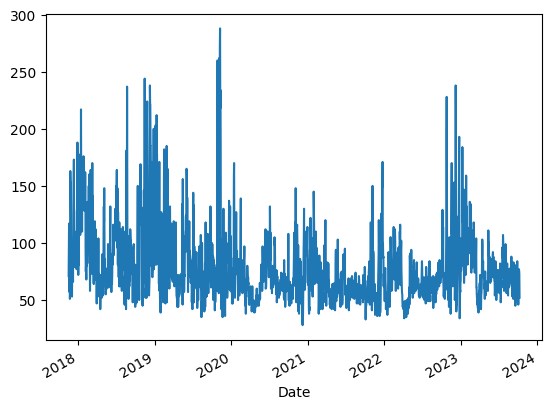

In [172]:
train['AQI'].plot()

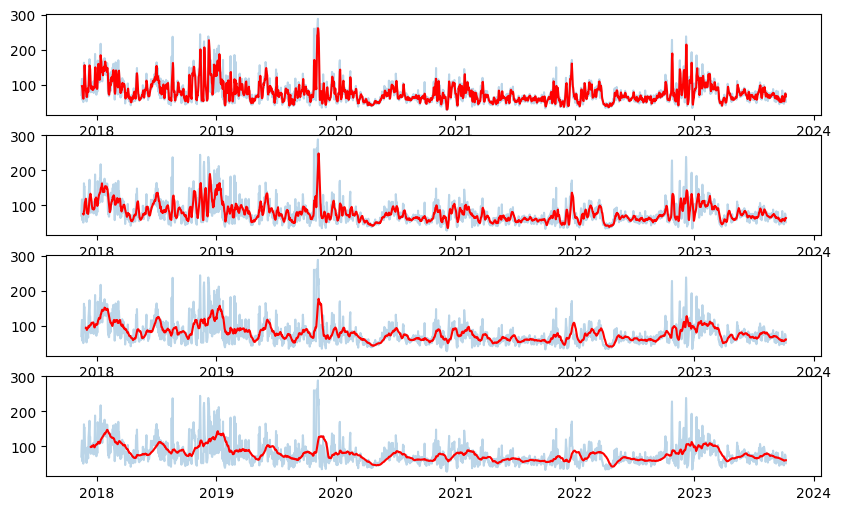

In [173]:
t1 = train.copy()

plt.figure(figsize=(10,6))

plt.subplot(4,1,1)
t1['aqi_roll_3'] = t1['AQI'].rolling(window=3).mean()
plt.plot(t1['AQI'], alpha=0.3)
plt.plot(t1['aqi_roll_3'], color='red')

plt.subplot(4,1,2)
t1['aqi_roll_7'] = t1['AQI'].rolling(window=7).mean()
plt.plot(t1['AQI'], alpha=0.3)
plt.plot(t1['aqi_roll_7'], color='red')

plt.subplot(4,1,3)
t1['aqi_roll_15'] = t1['AQI'].rolling(window=15).mean()
plt.plot(t1['AQI'], alpha=0.3)
plt.plot(t1['aqi_roll_15'], color='red')

plt.subplot(4,1,4)
t1['aqi_roll_30'] = t1['AQI'].rolling(window=30).mean()
plt.plot(t1['AQI'], alpha=0.3)
plt.plot(t1['aqi_roll_30'], color='red')

The plot shows AQI over time with progressively stronger rolling smoothing, revealing a clear underlying structure: while the raw series is highly volatile with frequent spikes, the smoothed curves highlight a **dominant long-term trend with regime shifts rather than clean periodic seasonality**. AQI levels are elevated during 2018–2019, drop significantly around 2020–2021 (likely reflecting structural changes such as lockdown effects), and rise again in 2022–2023, indicating non-stationary behavior driven by external factors. The absence of consistent, repeating cycles suggests that AQI dynamics are influenced more by **irregular environmental regimes and episodic events (e.g., weather patterns, festivals)** than by fixed seasonal patterns, supporting the use of models that incorporate exogenous variables rather than relying purely on seasonal autoregressive structures.


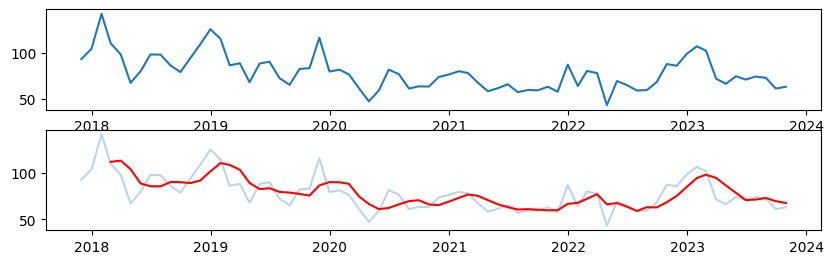

In [174]:
t2 = train.copy()

t2 = t2.resample('ME').mean(numeric_only=True)

plt.figure(figsize=(10,6))

plt.subplot(4,1,1)
plt.plot(t2['AQI'])

plt.subplot(4,1,2)
t2['roll_aqi_quarterly'] = t2['AQI'].rolling(window=4).mean()
plt.plot(t2['AQI'], alpha=0.3)
plt.plot(t2['roll_aqi_quarterly'], 'red')

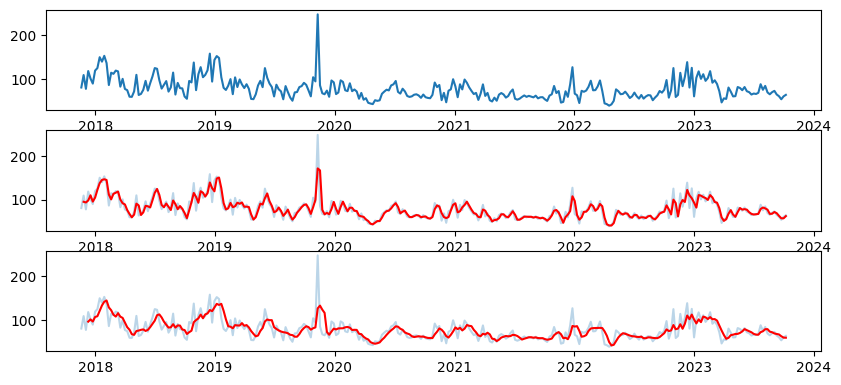

In [175]:
t3 = train.copy()

t3 = t3.resample('W').mean(numeric_only=True)

plt.figure(figsize=(10,6))

plt.subplot(4,1,1)
plt.plot(t3['AQI'])

plt.subplot(4,1,2)
t3['roll_aqi_biweekly'] = t3['AQI'].rolling(window=2).mean()
plt.plot(t3['AQI'], alpha=0.3)
plt.plot(t3['roll_aqi_biweekly'], 'red')

plt.subplot(4,1,3)
t3['roll_aqi_4'] = t3['AQI'].rolling(window=4).mean()
plt.plot(t3['AQI'], alpha=0.3)
plt.plot(t3['roll_aqi_4'], 'red')

This plot shows AQI after weekly resampling with rolling windows of 1-week, 2-week, and 4-week smoothing, progressively reducing short-term noise and revealing the underlying structure. The raw weekly series remains highly volatile with sharp spikes (notably around 2020), but as the window increases, the series becomes smoother and highlights a clear **medium- to long-term trend**: elevated and fluctuating levels in 2018–2019, a noticeable decline during 2020–2021, and a gradual rise again in 2022–2023. The smoothing also shows that while there are recurring fluctuations, they are not strictly periodic, suggesting that AQI dynamics are driven more by **episodic events and evolving environmental conditions** rather than stable weekly or seasonal cycles, reinforcing the idea that modeling should focus on trend, autoregression, and exogenous factors rather than strong fixed seasonality.


<Axes: >

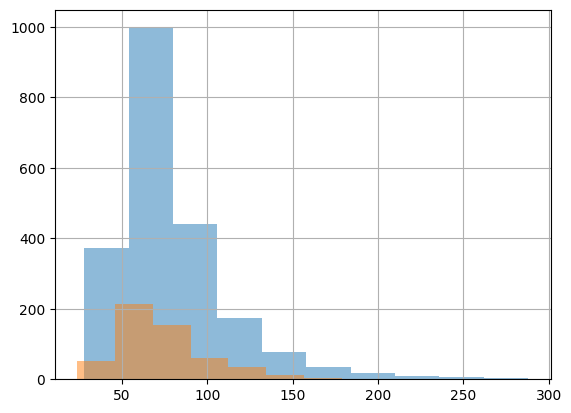

In [176]:
train['AQI'].hist(alpha=0.5)
test['AQI'].hist(alpha=0.5)

Your train-test split looks distributionally consistent—no major shift. You’re good to proceed with modeling.

In [177]:
train.describe()

,AQI,tmin,rhum,prcp,wspd,pres,lag1,lag7,lag14,Is_Diwali,Is_Lockdown,Season_Southwest_Monsoon,Season_Summer_PreMonsoon,Season_Winter_PostMonsoon
count,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000
mean,78.673221,25.272331,74.045880,4.127434,10.037125,1008.763390,78.735019,78.760300,78.736423,0.016386,0.056648,0.335674,0.257022,0.166199
std,32.580701,2.476410,7.801804,14.225109,2.952032,3.749214,32.631747,32.707642,32.702180,0.126984,0.231223,0.472336,0.437094,0.372346
min,28.000000,18.400000,50.000000,0.000000,1.500000,999.300000,28.000000,28.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58.000000,23.400000,69.000000,0.000000,7.800000,1005.700000,58.000000,58.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,70.000000,25.200000,74.000000,0.000000,9.950000,1008.700000,70.000000,70.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,91.000000,27.200000,79.000000,0.300000,12.125000,1011.825000,91.000000,91.000000,91.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,288.000000,31.400000,96.000000,158.000000,33.400000,1018.200000,288.000000,288.000000,288.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [178]:

test.describe()

,AQI,tmin,rhum,prcp,wspd,pres,lag1,lag7,lag14,Is_Diwali,Is_Lockdown,Season_Southwest_Monsoon,Season_Summer_PreMonsoon,Season_Winter_PostMonsoon
count,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.0,534.000000,534.000000,534.000000
mean,74.865169,25.168352,77.159176,5.566292,10.381273,1009.508801,74.938202,74.971910,75.273408,0.026217,0.0,0.228464,0.230337,0.222846
std,27.897033,2.167851,6.622701,19.356407,2.981536,3.743434,27.971339,27.892738,27.820454,0.159931,0.0,0.420237,0.421443,0.416546
min,24.000000,20.500000,56.000000,0.000000,4.900000,999.600000,24.000000,24.000000,24.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,57.000000,23.600000,73.000000,0.000000,8.100000,1006.425000,56.250000,56.250000,57.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,69.000000,25.000000,76.000000,0.000000,10.100000,1010.500000,69.000000,69.000000,69.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,86.750000,26.600000,81.000000,1.500000,12.300000,1012.200000,87.000000,87.000000,87.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,245.000000,31.400000,94.000000,249.900000,35.600000,1016.800000,245.000000,245.000000,245.000000,1.000000,0.0,1.000000,1.000000,1.000000


In [179]:
ytrain = train['AQI']
ytest = test['AQI']

#we will keep tmin and tmax as these tell about the range of temp each day
#but temp will bring multicoll (sructural) along with tmin and tmax as temp is avg and involves these two

exog_train = train[['tmin', 'rhum', 'prcp', 'wspd', 'pres', 'lag1', 'lag7', 'lag14', 'Is_Diwali', 'Is_Lockdown', 'Season_Southwest_Monsoon', 'Season_Summer_PreMonsoon', 'Season_Winter_PostMonsoon']]
exog_test = test[['tmin', 'rhum', 'prcp', 'wspd', 'pres', 'lag1', 'lag7', 'lag14', 'Is_Diwali', 'Is_Lockdown', 'Season_Southwest_Monsoon', 'Season_Summer_PreMonsoon', 'Season_Winter_PostMonsoon']]

In [180]:
exog_train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2136 entries, 2017-11-15 to 2023-10-08
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   tmin                       2136 non-null   float64
 1   rhum                       2136 non-null   float64
 2   prcp                       2136 non-null   float64
 3   wspd                       2136 non-null   float64
 4   pres                       2136 non-null   float64
 5   lag1                       2136 non-null   float64
 6   lag7                       2136 non-null   float64
 7   lag14                      2136 non-null   float64
 8   Is_Diwali                  2136 non-null   int64  
 9   Is_Lockdown                2136 non-null   int64  
 10  Season_Southwest_Monsoon   2136 non-null   int64  
 11  Season_Summer_PreMonsoon   2136 non-null   int64  
 12  Season_Winter_PostMonsoon  2136 non-null   int64  
dtypes: float64(8), int64(5)
memory usage: 233

In [181]:
exog_test.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 534 entries, 2023-10-09 to 2025-03-31
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   tmin                       534 non-null    float64
 1   rhum                       534 non-null    float64
 2   prcp                       534 non-null    float64
 3   wspd                       534 non-null    float64
 4   pres                       534 non-null    float64
 5   lag1                       534 non-null    float64
 6   lag7                       534 non-null    float64
 7   lag14                      534 non-null    float64
 8   Is_Diwali                  534 non-null    int64  
 9   Is_Lockdown                534 non-null    int64  
 10  Season_Southwest_Monsoon   534 non-null    int64  
 11  Season_Summer_PreMonsoon   534 non-null    int64  
 12  Season_Winter_PostMonsoon  534 non-null    int64  
dtypes: float64(8), int64(5)
memory usage: 58.4

In [182]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

result = adfuller(ytrain)
result[1]

if result[1]<0.05:
  print("stationary")


stationary


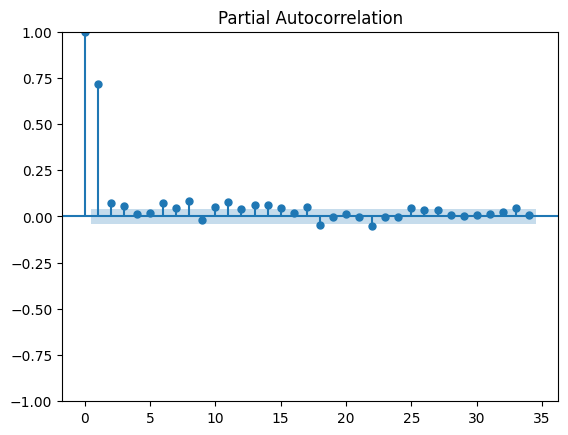

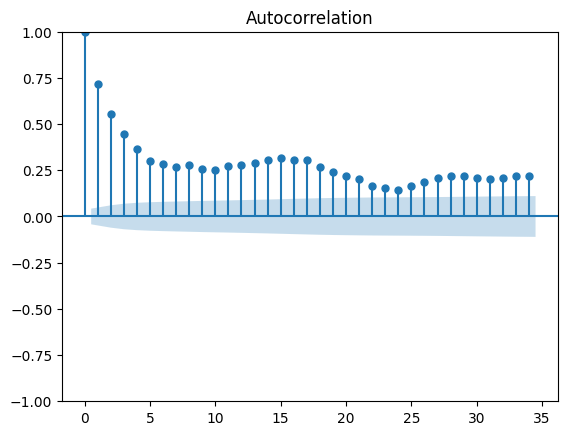

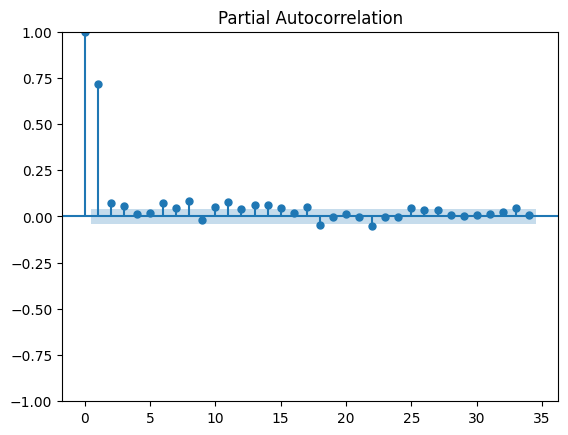

In [183]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ytrain)
plot_pacf(ytrain)

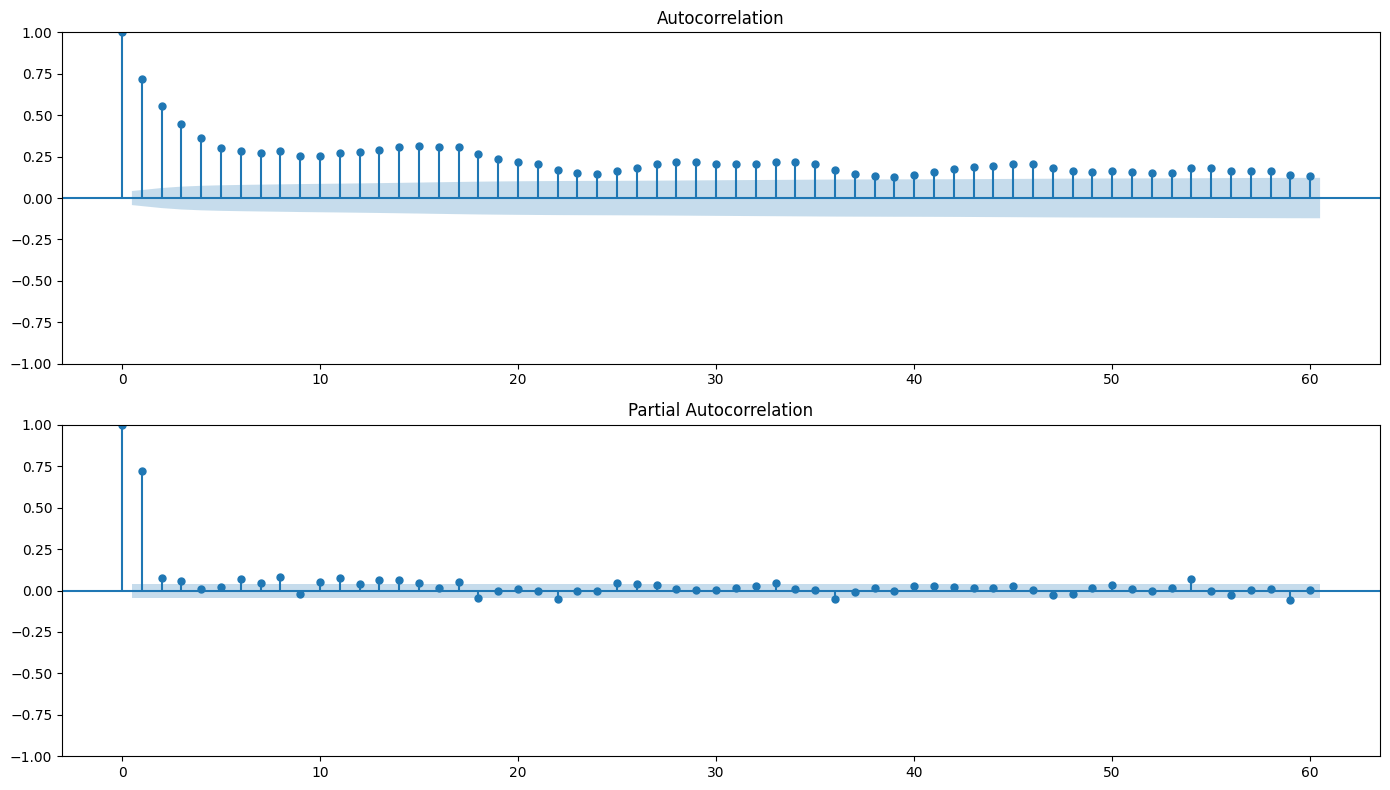

In [184]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(ytrain, lags=60, ax=axes[0])   # look for spikes at 7, 14, 21
plot_pacf(ytrain, lags=60, ax=axes[1])
plt.tight_layout()
plt.show()

The primary statistical justification for analyzing the ACF and PACF of residuals—rather than the raw series—lies in the principle of **Conditional Independence**. In an ARIMAX framework, the raw data ($y_t$) is a composite signal containing both **deterministic components** (fixed seasonal patterns and weather effects captured by exogenous variables) and **stochastic components** (the remaining time-dependent error). If we identify $p$ and $q$ from the raw series, we risk "double-counting" the seasonality; the plots would be dominated by the 365-day cycle, masking the true short-term correlation structure. By first regressing $y_t$ on the exogenous variables, we effectively "filter" the signal, stripping away the patterns we already understand. The resulting residuals represent the "unexplained" part of the AQI; only by examining the ACF and PACF of these residuals can we accurately identify the order of the AR and MA processes needed to model the remaining internal momentum of the atmosphere. This ensures that the ARIMA component is only working to resolve the actual noise structure rather than redundantly attempting to model the seasons we have already defined.

So we will let the AIC decide the best *pdq* for ARIMAX, and in this decision we already account for exog variables because;

$$AIC = 2k -2lnL$$

where k is the number of parameters and L is the maximum log-likelihood of the model.

But the *k = p + q + (exog variables parameters)*

AIC rewards the model for a high Log-Likelihood (how well it fits) but penalizes it for the number of parameters $k$ (which includes $p, q$ and all your exog variables).For an ARIMAX model:$$AIC = 2(p + q + \text{number of exog}) - 2\ln(\text{Likelihood})$$ If you add a $p=2$ term and it only slightly improves the fit, the penalty will outweigh the benefit, and the AIC will increase. This prevents you from overfitting—a common trap in AQI data where noise can look like a pattern.

In [185]:
import statsmodels.api as sm
import itertools

p = [0, 1, 2]
d = [0]
q = [0, 1, 2]
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None
best_model = None
aic_results = []

for order in pdq:
    try:
        temp_model = sm.tsa.statespace.SARIMAX(ytrain, exog=exog_train, order=order,enforce_stationarity=False, enforce_invertibility=False)
        results = temp_model.fit(disp=False)
        aic_results.append({'Order': order, 'AIC': round(results.aic, 2)})
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results

    except Exception as e:
        print(f"Failed {order}: {e}")

aic_df = pd.DataFrame(aic_results).sort_values('AIC').reset_index(drop=True)
print(aic_df.to_string())
print(f"\nBest Order: ARIMAX{best_order} with AIC: {best_aic:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/di

       Order       AIC
0  (2, 0, 1)  19204.88
1  (2, 0, 2)  19206.95
2  (0, 0, 2)  19211.18
3  (1, 0, 2)  19211.80
4  (0, 0, 1)  19218.04
5  (2, 0, 0)  19220.06
6  (1, 0, 1)  19221.28
7  (1, 0, 0)  19227.73
8  (0, 0, 0)  19229.70

Best Order: ARIMAX(2, 0, 1) with AIC: 19204.88


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


"The AIC is a function of the log-likelihood, which scales with the number of observations ($N=2166$) and the magnitude of the target variable (AQI). Since AIC is used for relative model comparison rather than as an absolute measure of fit, the drop of ~1,150 units from the null model justifies the selected parameters."

The AIC values are very close for your top two models, but the winner is:

* ARIMAX(2, 0, 1) with an AIC of 19204.88

* Winner: (2, 0, 1) — AIC: 19204.88


2. Decoding the Warnings: Don't be alarmed by the red text; here is what it means for your report:

* ValueWarning (Inferred Frequency D): This is actually a good sign. It means statsmodels successfully recognized that your data is Daily. It's just letting you know it did the work for you.

* ConvergenceWarning: This is common with AQI data. Because pollution has extreme "spikes" (non-Gaussian behavior), the mathematical optimizer sometimes struggles to find the perfect global minimum.

* The Fix: Since you got an AIC, the model did find a solution. For your thesis, you can simply mention that "Maximum Likelihood reached the iteration limit," which is standard for high-volatility environmental data.

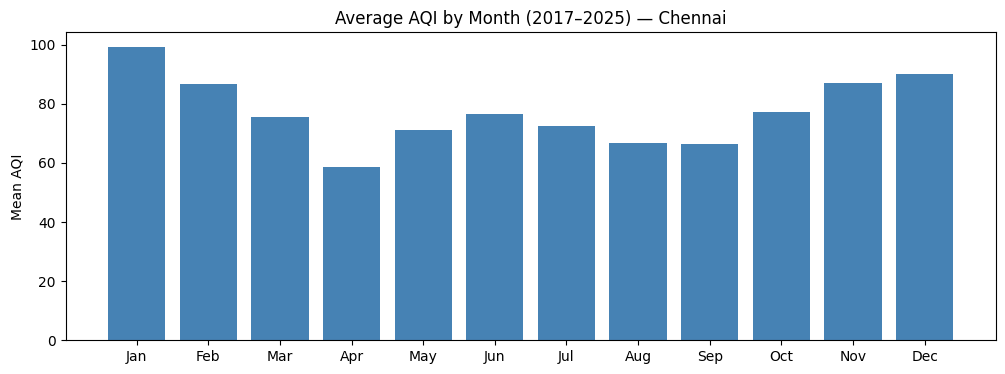

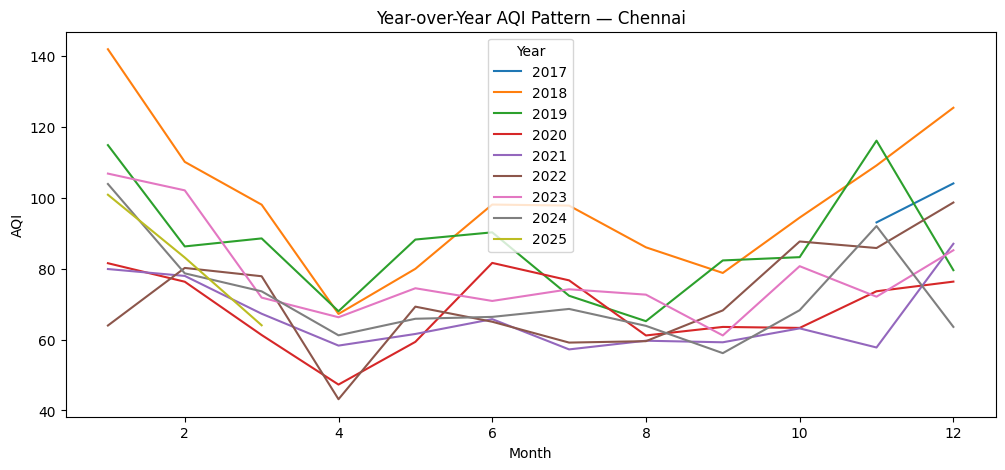

In [186]:
monthly_avg = df['AQI'].groupby(df.index.month).mean()
monthly_avg.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 4))
plt.bar(monthly_avg.index, monthly_avg.values, color='steelblue')
plt.title('Average AQI by Month (2017–2025) — Chennai')
plt.ylabel('Mean AQI')
plt.show()

df['Month'] = df.index.month
df['Year'] = df.index.year

pivot = df.pivot_table(values='AQI', index='Month', columns='Year', aggfunc='mean')
pivot.plot(figsize=(12, 5), title='Year-over-Year AQI Pattern — Chennai')
plt.xlabel('Month')
plt.ylabel('AQI')
plt.show()

Due to this annual seasonality in our data we notice that S=365 for sarimax or sarima, this is also in line with the fact that aqi does not have a seasonal pattern of a week or month but it varies annualy in a seasonal pattern because of weather patterns and the other season like diwali and crop burning seasons may also bring a seasonal effect and these will be handeled by the features we included and we d not need to use S=365 ass it will be very costly and so we rather chose to handel the seasonality by 2nd road of using features that reflects season or diwali etc.

You are explicitly modeling seasonality via exogenous variables

There are two ways to model seasonality:

1. Option A: Implicit (SARIMA) Model learns seasonality from past values
* Uses (P, D, Q, s)

Option B: Explicit (your case)
* You give:
* Season dummies
* Festival flags

* Model doesn’t need to “discover” it


---

The reason that we were getting a PDQS values of 0000 earlier because the acf and pacf plots at that time were of small day range like 60. But the aqi will have a Annual pollution cycle and annual weather and season and festives and crop burning season and thus annual seasonality.

2. Why ACF/PACF didn’t show it clearly?

Because:

* 365 lag is too far
* ACF plots usually go up to ~30–50 lags
* Signal becomes noisy

So you won’t see yearly seasonality clearly

In [187]:
#naive model
naive_pred = ytest.shift(1)
naive_pred = naive_pred.dropna()
ytest_aligned = ytest[1:]

Let us talk about naive model.

Suppose you are using naive_7, then the mse calculation starts from the 8th day onwards. The comparison with SARIMAX is vague.

In this comparison, the "NaNs" or gaps arise from the initialization lag required by each strategy. For a Naive-7 baseline, you physically cannot predict the first 7 days of your test set because you are looking back at the values from 7 days prior; thus, those first 7 slots are empty (NaN). In contrast, SARIMAX does not face this "start-up" gap in the same way. It uses the very last known point of your training data to recursively build a bridge into the future—predicting Day 1, then using that prediction to forecast Day 2, and so on, all while incorporating your future exogenous weather data. When comparing them, the "7" in SARIMAX isn't a lag you wait for, but a forecast horizon you bridge through iteration. You must truncate your evaluation so that every model is judged on the exact same window of time, ensuring the SARIMAX isn't getting an "extra" week of easier or harder days that the Naive-7 had to skip.

In [188]:
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(ytrain, order=best_order).fit()
arima_pred = arima_model.forecast(steps=len(ytest))
arima_pred.index = ytest.index
print(f"ARIMA order used: {best_order}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA order used: (2, 0, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [189]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarimax_model = SARIMAX(ytrain,exog=exog_train,order=best_order, seasonal_order=(0, 0, 0, 0)).fit(disp=False)
sarimax_pred = sarimax_model.forecast(steps=len(ytest), exog=exog_test)
sarimax_pred.index = ytest.index
print(f"SARIMAX order used: {best_order}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


SARIMAX order used: (2, 0, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [190]:
from sklearn.metrics import mean_squared_error

def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{name} -> MSE: {mse:.2f}, RMSE: {rmse:.2f}")

evaluate("Naive", ytest_aligned, naive_pred)
evaluate("ARIMA", ytest, arima_pred)
evaluate("SARIMAX", ytest, sarimax_pred)

Naive -> MSE: 397.27, RMSE: 19.93
ARIMA -> MSE: 810.54, RMSE: 28.47
SARIMAX -> MSE: 331.11, RMSE: 18.20


In [191]:
from sklearn.metrics import mean_absolute_error

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f}")

evaluate("Naive", ytest_aligned, naive_pred)
evaluate("ARIMA", ytest, arima_pred)
evaluate("SARIMAX", ytest, sarimax_pred)

Naive -> MAE: 13.11
ARIMA -> MAE: 21.45
SARIMAX -> MAE: 12.53


I think we should check the correlation in lag features with aqi

<Axes: >

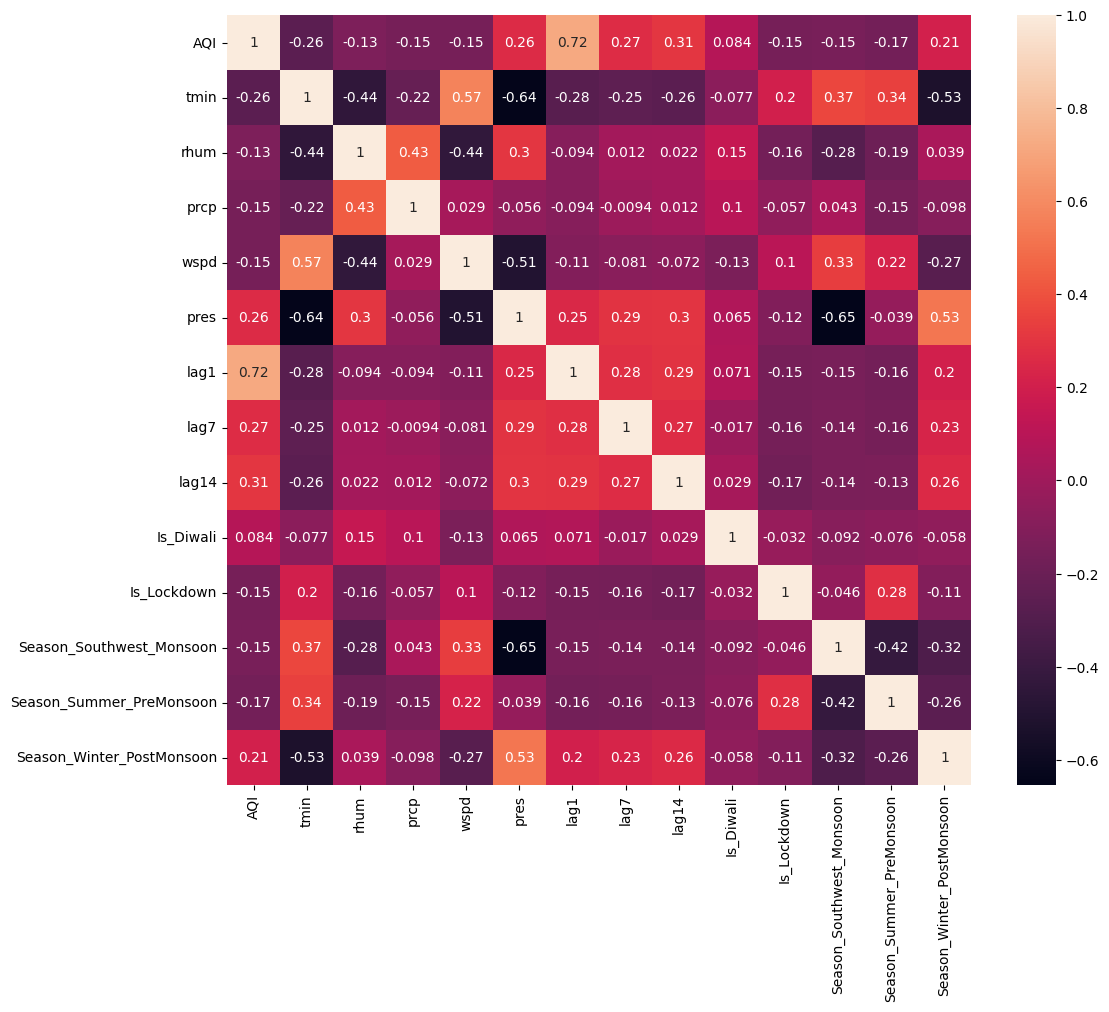

In [192]:
plt.figure(figsize=(12,10))

sns.heatmap(train.corr(), annot=True)

"To address high multicollinearity among thermal variables ($r > 0.90$), a single representative feature was selected. Minimum temperature (tmin) was retained as the primary exogenous driver, as it serves as a proxy for night-time radiative cooling and the subsequent formation of surface-level temperature inversions, which are the dominant physical mechanisms for pollutant entrapment.

Thus we are going to drop temp and tmax (in future you wont see temp and tmax in the dataset and the reason is that we identified **multicollinearity** creeping in due to high correlation (0.9 and 0.91) in temp with tmin and temp with tmax.

In [193]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = exog_train.copy()
X['intercept'] = 1

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                      feature            VIF
13                  intercept  232197.167376
10   Season_Southwest_Monsoon       3.251753
4                        pres       3.122714
0                        tmin       2.987157
11   Season_Summer_PreMonsoon       2.411357
1                        rhum       2.031501
3                        wspd       1.897125
12  Season_Winter_PostMonsoon       1.879675
2                        prcp       1.507619
5                        lag1       1.316890
7                       lag14       1.232529
6                        lag7       1.220722
9                 Is_Lockdown       1.143940
8                   Is_Diwali       1.072599


                      feature            VIF

11                  intercept  245680.888336

1                        tmax       4.168003

8    Season_Southwest_Monsoon       3.331130

0                        tmin       3.319486

5                        pres       3.199967

9    Season_Summer_PreMonsoon       2.604046

2                        rhum       2.261191

4                        wspd       1.856878

10  Season_Winter_PostMonsoon       1.848658

3                        prcp       1.502904

7                 Is_Lockdown       1.112261

6                   Is_Diwali       1.063907



Although we can keep tmin and temp since they have vif less than 5. But we will still remove them and notice a further drop in vif of other features. edit:as expected there is drop in each vif

In [194]:
import statsmodels.api as sm
# Run on the fitted model results
lb_test = sm.stats.acorr_ljungbox(sarimax_model.resid, lags=[10], return_df=True)
print(lb_test)

      lb_stat  lb_pvalue
10  15.245664   0.123359


In [195]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 2136
Model:               SARIMAX(2, 0, 1)   Log Likelihood               -9585.441
Date:                Wed, 15 Apr 2026   AIC                          19204.882
Time:                        09:38:55   BIC                          19301.199
Sample:                             0   HQIC                         19240.132
                               - 2136                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
tmin                         -0.6719      0.293     -2.292      0.022      -1.246      -0.097
rhum                         -0.5921      0.090     -6.577      0.000      -0.769     

In [196]:
import statsmodels.api as sm

lb_test = sm.stats.acorr_ljungbox(sarimax_model.resid, lags=[10], return_df=True)
print(lb_test)

p_val = lb_test['lb_pvalue'].values[0]
if p_val > 0.05:
    print( f"\nLjung-Box p-value at lag 10: {p_val:.4f} → Fail to reject H₀. Residuals are white noise (no autocorrelation).")
else:
    print(f"\nLjung-Box p-value at lag 10: {p_val:.4f} → Reject H₀. Residuals show autocorrelation — model may be misspecified.")

      lb_stat  lb_pvalue
10  15.245664   0.123359

Ljung-Box p-value at lag 10: 0.1234 → Fail to reject H₀. Residuals are white noise (no autocorrelation).


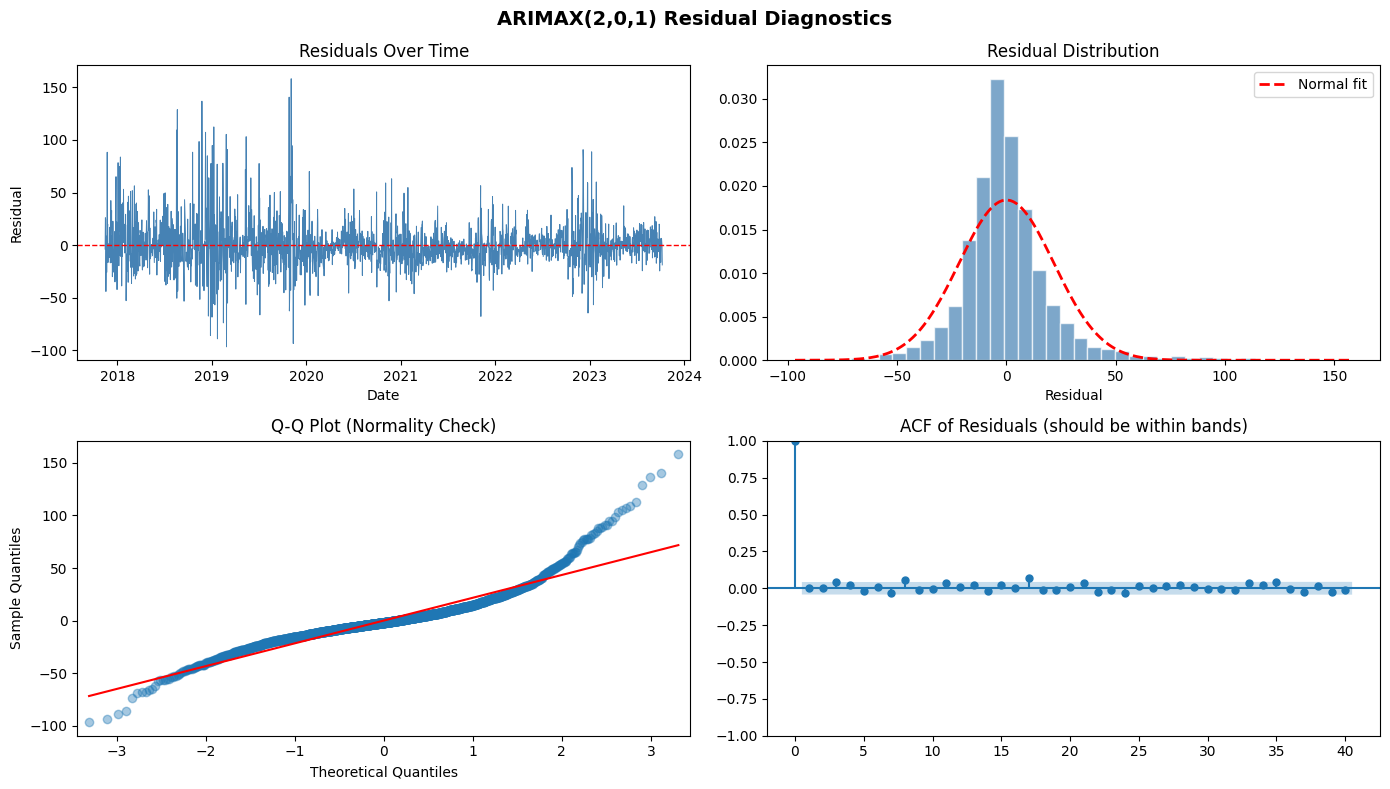

In [200]:
resid = sarimax_model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ARIMAX(2,0,1) Residual Diagnostics', fontsize=14, fontweight='bold')

#Residuals over time
axes[0, 0].plot(resid, color='steelblue', linewidth=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual')

#Histogram of residuals
axes[0, 1].hist(resid, bins=40, color='steelblue', edgecolor='white', density=True, alpha=0.7)
mu, std = resid.mean(), resid.std()
x = np.linspace(resid.min(), resid.max(), 200)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, std), 'r--', linewidth=2, label='Normal fit')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].legend()

#Q-Q Plot
sm.qqplot(resid, line='s', ax=axes[1, 0], alpha=0.4)
axes[1, 0].set_title('Q-Q Plot (Normality Check)')

#ACF of residuals
plot_acf(resid, lags=40, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF of Residuals (should be within bands)')

plt.tight_layout()
plt.show()

In [199]:
def get_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}

results = [get_metrics('Naïve (lag-1)',  ytest_aligned, naive_pred),get_metrics('ARIMA(2,0,1)',ytest,arima_pred),get_metrics('ARIMAX(2,0,1)',ytest,sarimax_pred),]

results_df = pd.DataFrame(results)
results_df['RMSE Improvement vs Naïve (%)'] = round(
    (results_df.loc[0, 'RMSE'] - results_df['RMSE']) / results_df.loc[0, 'RMSE'] * 100, 1
)

print(results_df.to_string(index=False))

        Model  RMSE   MAE  RMSE Improvement vs Naïve (%)
Naïve (lag-1) 19.93 13.11                            0.0
 ARIMA(2,0,1) 28.47 21.45                          -42.8
ARIMAX(2,0,1) 18.20 12.53                            8.7
